# 01 — NHANES LDL-C (2015 – Aug 2023) vs the team's `LDL`, `LDL_sd` columns

The team's `nhanes_rf_distributions.csv` records per-(sex, 5-yr age band) `LDL` and `LDL_sd` for use as an arithmetic-scale lognormal moment-match in the simulation. Values look like they're in **mmol/L** (e.g., Male 60 = 2.85, SD 0.99 → matches a typical adult LDL of ~110 mg/dL).

This notebook pulls LDL-C from three NHANES cycles spanning 2015 – August 2023:

- **I** : 2015–2016 (DEMO_I + TRIGLY_I)
- **P** : 2017–March 2020 prepandemic combined (P_DEMO + P_TRIGLY)
- **L** : August 2021 – August 2023 (DEMO_L + TRIGLY_L)

LDL-C in NHANES is `LBDLDLSI` — the Friedewald-calculated value reported in mmol/L (the same SI units the team's column uses). It is defined only when triglycerides < 400 mg/dL; cases with TG ≥ 400 are NaN by design. We compute survey-weighted mean and SD per (sex, 5-yr age band) directly on this column.

Each cycle has its own fasting-subsample weight (`WTSAF2YR` or `WTSAFPRP`). For pooling we use NCHS's standard rescale: weight × (cycle months / total months across cycles), so each cycle contributes proportionally to its calendar coverage. With 24 + 39 + 25 = 88 months, the scale factors are roughly 0.27 / 0.44 / 0.28.


## 1. Download and parse the three TRIGLY + DEMO releases


In [1]:
import os, urllib.request, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

ROOT = Path(os.path.abspath(os.path.join('..')))
DATA = ROOT / 'data'
DERIVED = DATA / 'derived'
DERIVED.mkdir(parents=True, exist_ok=True)

# raw dirs per cycle
CYCLES = {
    'I': {
        'dir': DATA / 'raw' / 'nhanes' / '2015_2016',
        'months': 24,
        'demo_file': 'DEMO_I.xpt',
        'trig_file': 'TRIGLY_I.xpt',
        'demo_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DEMO_I.xpt',
        'trig_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/TRIGLY_I.xpt',
        'wt_col': 'WTSAF2YR',
    },
    'P': {
        'dir': DATA / 'raw' / 'nhanes' / '2017_2020_prepandemic',
        'months': 39,
        'demo_file': 'P_DEMO.xpt',
        'trig_file': 'P_TRIGLY.xpt',
        'demo_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt',
        'trig_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TRIGLY.xpt',
        'wt_col': 'WTSAFPRP',
    },
    'L': {
        'dir': DATA / 'raw' / 'nhanes' / '2021_2023',
        'months': 25,
        'demo_file': 'DEMO_L.xpt',
        'trig_file': 'TRIGLY_L.xpt',
        'demo_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt',
        'trig_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TRIGLY_L.xpt',
        'wt_col': 'WTSAF2YR',
    },
}
total_months = sum(c['months'] for c in CYCLES.values())

for tag, c in CYCLES.items():
    c['dir'].mkdir(parents=True, exist_ok=True)
    for fname, url in [(c['demo_file'], c['demo_url']),
                       (c['trig_file'], c['trig_url'])]:
        out = c['dir'] / fname
        if out.exists():
            continue
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=120) as r:
            out.write_bytes(r.read())

def parse_cycle(tag, c):
    demo = pd.read_sas(c['dir'] / c['demo_file'])
    trig = pd.read_sas(c['dir'] / c['trig_file'])
    demo = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR']]
    # NCHS keeps the fasting-subsample weight in the lab file, not DEMO
    trig = trig[['SEQN', c['wt_col'], 'LBDLDLSI']].rename(
        columns={c['wt_col']: 'WT_FAST', 'LBDLDLSI': 'ldl_mmol'})
    df = demo.merge(trig, on='SEQN', how='inner')
    df['sex'] = df['RIAGENDR'].map({1.0: 'Male', 2.0: 'Female'})
    df['age_years'] = df['RIDAGEYR'].astype(float)
    df['ldl_mmol']  = df['ldl_mmol'].astype(float)
    df['cycle'] = tag
    df['cycle_months'] = c['months']
    df['WT_FAST'] = df['WT_FAST'].astype(float)
    df['WT_POOLED'] = df['WT_FAST'] * (c['months'] / total_months)
    return df[['SEQN','cycle','sex','age_years','ldl_mmol',
               'WT_FAST','WT_POOLED']]

cycles_dfs = {tag: parse_cycle(tag, c) for tag, c in CYCLES.items()}
pool = pd.concat(cycles_dfs.values(), ignore_index=True)

# valid LDL = Friedewald-able (TG<400), fasting weight > 0
m = pool['ldl_mmol'].notna() & pool['WT_FAST'].fillna(0).gt(0)
ana = pool[m].copy()
print('Per-cycle valid-LDL counts (fasting subsample with TG<400):')
print(ana.groupby('cycle').size().to_string())
print(f'\nTotal valid pooled rows: n = {len(ana):,}')
print(f'LDL (mmol/L) summary: mean = {ana["ldl_mmol"].mean():.3f}, '
      f'median = {ana["ldl_mmol"].median():.3f}')


Per-cycle valid-LDL counts (fasting subsample with TG<400):
cycle
I    2699
L    3480
P    4617

Total valid pooled rows: n = 10,796
LDL (mmol/L) summary: mean = 2.741, median = 2.638


## 2. Per-(sex, 5-yr age band) weighted mean and SD, pooled and per-cycle

Match the team's binning: 5-year bands starting at 25, 30, ..., 80 (NHANES top-codes age at 80, so the 80 row covers exactly age = 80).


In [2]:
def w_mean(y, w): return float(np.average(y, weights=w))
def w_sd(y, w):
    mu = w_mean(y, w)
    return float(np.sqrt(np.average((y - mu)**2, weights=w)))

edges = list(range(25, 85, 5)) + [85]

def per_bin(d, wcol, label):
    rows = []
    for sex in ['Female', 'Male']:
        for a0, a1 in zip(edges[:-1], edges[1:]):
            sub = d[(d['sex'] == sex)
                    & (d['age_years'] >= a0)
                    & (d['age_years'] < a1)]
            if len(sub) < 30:
                continue
            y = sub['ldl_mmol'].values
            w = sub[wcol].values
            rows.append({
                'sex': sex, 'age5': a0, 'n': len(sub),
                f'mean_{label}': w_mean(y, w),
                f'sd_{label}':   w_sd(y, w),
            })
    return pd.DataFrame(rows)

per_I = per_bin(ana[ana['cycle']=='I'], 'WT_FAST', 'I')
per_P = per_bin(ana[ana['cycle']=='P'], 'WT_FAST', 'P')
per_L = per_bin(ana[ana['cycle']=='L'], 'WT_FAST', 'L')
per_pool = per_bin(ana, 'WT_POOLED', 'pool')

# n per cycle
n_I = per_I.rename(columns={'n':'n_I'})[['sex','age5','n_I']]
n_P = per_P.rename(columns={'n':'n_P'})[['sex','age5','n_P']]
n_L = per_L.rename(columns={'n':'n_L'})[['sex','age5','n_L']]

tab = (per_pool
       .merge(per_I[['sex','age5','mean_I','sd_I']], on=['sex','age5'], how='left')
       .merge(per_P[['sex','age5','mean_P','sd_P']], on=['sex','age5'], how='left')
       .merge(per_L[['sex','age5','mean_L','sd_L']], on=['sex','age5'], how='left')
       .merge(n_I, on=['sex','age5'], how='left')
       .merge(n_P, on=['sex','age5'], how='left')
       .merge(n_L, on=['sex','age5'], how='left'))
tab = tab.rename(columns={'n':'n_pool'})
print('Pooled mean / SD per cell (mmol/L), with per-cycle means for context:')
print(tab[['sex','age5','n_pool','n_I','n_P','n_L',
           'mean_pool','sd_pool','mean_I','mean_P','mean_L']]
      .round(3).to_string(index=False))


Pooled mean / SD per cell (mmol/L), with per-cycle means for context:
   sex  age5  n_pool  n_I  n_P  n_L  mean_pool  sd_pool  mean_I  mean_P  mean_L
Female    25     362  103  154  105      2.567    0.876   2.626   2.475   2.647
Female    30     411   90  185  136      2.682    0.754   2.577   2.738   2.689
Female    35     377   95  161  121      2.785    0.744   2.746   2.758   2.865
Female    40     393   96  160  137      2.851    0.831   2.934   2.847   2.785
Female    45     355  109  145  101      3.050    0.783   3.163   2.958   3.061
Female    50     406   94  185  127      3.143    0.927   3.385   3.015   3.139
Female    55     439  103  207  129      3.271    0.980   3.142   3.372   3.222
Female    60     543  102  215  226      2.987    0.873   3.066   2.851   3.132
Female    65     470  106  158  206      2.924    0.984   2.816   3.006   2.923
Female    70     314   56  118  140      2.913    1.128   3.303   2.814   2.821
Female    75     226   51   78   97      2.771    

## 3. Side-by-side comparison vs the team's `nhanes_rf_distributions.csv`

Load the team's LDL columns and join on (sex, age5).


In [3]:
COLLEAGUE = (ROOT.parent / 'vivarium_csu_mace_rct'
             / 'src' / 'vivarium_csu_mace_rct' / 'data'
             / 'nhanes_rf_distributions.csv')
coll = pd.read_csv(COLLEAGUE).rename(columns={'Sex': 'sex'})
coll = coll[['age5', 'sex', 'LDL', 'LDL_sd']].rename(
    columns={'LDL': 'mean_team', 'LDL_sd': 'sd_team'})

cmp_ = tab.merge(coll, on=['sex', 'age5'], how='left')
cmp_['d_mean'] = cmp_['mean_pool'] - cmp_['mean_team']
cmp_['d_sd']   = cmp_['sd_pool']   - cmp_['sd_team']
cmp_['pct_d_mean'] = 100 * cmp_['d_mean'] / cmp_['mean_team']
cmp_['pct_d_sd']   = 100 * cmp_['d_sd']   / cmp_['sd_team']

print('Pooled NHANES (I+P+L, cycle-month-weighted) vs team\'s table (mmol/L):')
cols = ['sex','age5','n_pool',
        'mean_pool','mean_team','d_mean','pct_d_mean',
        'sd_pool','sd_team','d_sd','pct_d_sd']
print(cmp_[cols].round(3).to_string(index=False))

print()
print('Summary residuals across the 24 cells:')
rms_m = float(np.sqrt(np.nanmean(cmp_['d_mean']**2)))
rms_s = float(np.sqrt(np.nanmean(cmp_['d_sd']**2)))
bias_m = float(np.nanmean(cmp_['d_mean']))
bias_s = float(np.nanmean(cmp_['d_sd']))
print(f'  mean — bias (ours minus team) = {bias_m:+.4f}, RMS = {rms_m:.4f} mmol/L')
print(f'  sd   — bias                   = {bias_s:+.4f}, RMS = {rms_s:.4f} mmol/L')
print(f'  ({100*bias_m/cmp_["mean_team"].mean():+.2f} % of team\'s mean, {100*bias_s/cmp_["sd_team"].mean():+.2f} % of team\'s SD)')


Pooled NHANES (I+P+L, cycle-month-weighted) vs team's table (mmol/L):
   sex  age5  n_pool  mean_pool  mean_team  d_mean  pct_d_mean  sd_pool  sd_team   d_sd  pct_d_sd
Female    25     362      2.567      2.538   0.029       1.144    0.876    0.814  0.062     7.666
Female    30     411      2.682      2.672   0.011       0.402    0.754    0.750  0.004     0.585
Female    35     377      2.785      2.783   0.002       0.070    0.744    0.711  0.033     4.593
Female    40     393      2.851      2.842   0.008       0.291    0.831    0.833 -0.002    -0.246
Female    45     355      3.050      3.056  -0.006      -0.192    0.783    0.798 -0.015    -1.843
Female    50     406      3.143      3.166  -0.023      -0.725    0.927    0.952 -0.025    -2.639
Female    55     439      3.271      3.243   0.028       0.871    0.980    0.986 -0.006    -0.625
Female    60     543      2.987      3.026  -0.039      -1.276    0.873    0.901 -0.028    -3.054
Female    65     470      2.924      2.903   0.0

## 4. Plot — mean and SD by age, by sex

Black points with error bars: pooled NHANES with binomial-style 95 % CI on the mean (`±1.96 × SD/√n`).  Red squares: team's table.  Light grey points: per-cycle (I/P/L) means so you can see whether the gap is a sample-drift artefact or a systematic offset.


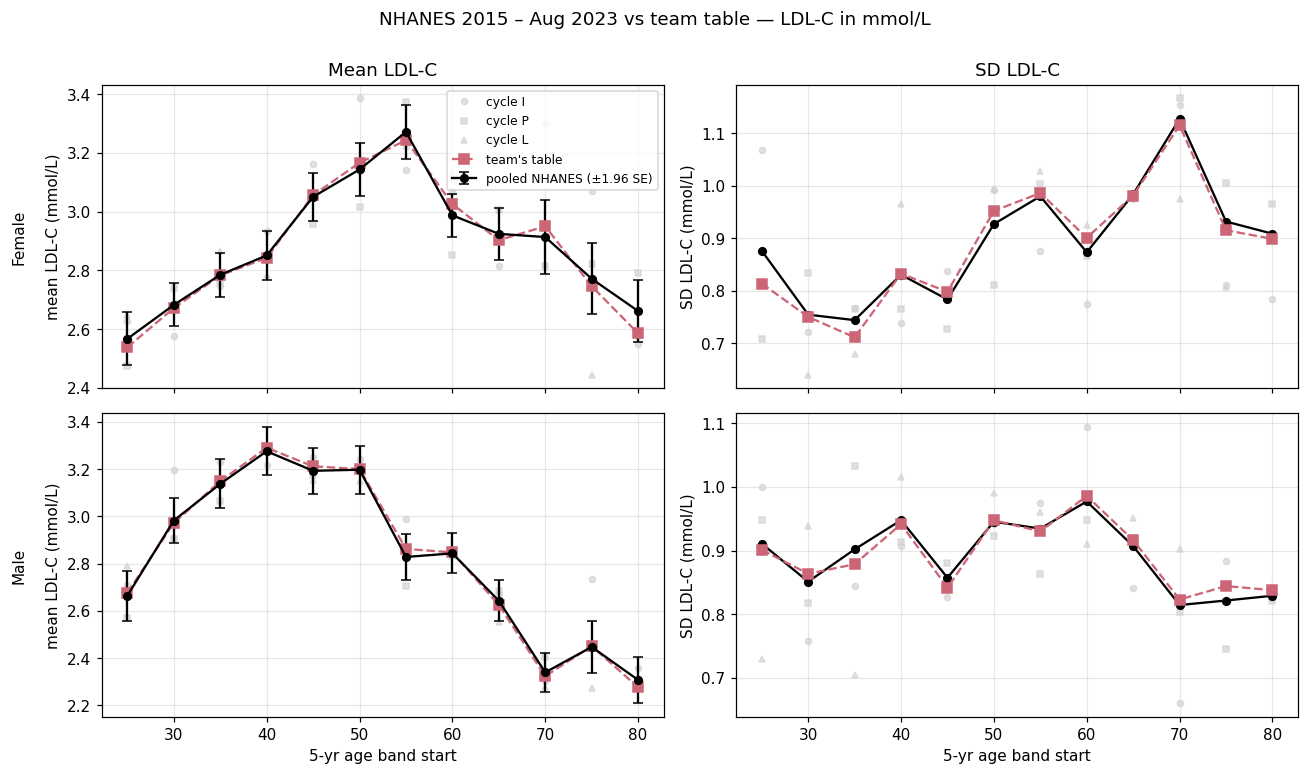

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for row, sex in enumerate(['Female', 'Male']):
    c = cmp_[cmp_['sex'] == sex].sort_values('age5')
    se_mean = c['sd_pool'] / np.sqrt(c['n_pool'])

    ax = axes[row, 0]
    # per-cycle in grey (no error bars to keep visual clean)
    for cy, mk in [('I','o'),('P','s'),('L','^')]:
        ax.plot(c['age5'], c[f'mean_{cy}'], mk, color='lightgrey',
                markersize=4, alpha=0.7, label=f'cycle {cy}' if row==0 else None)
    ax.errorbar(c['age5'], c['mean_pool'], yerr=1.96*se_mean,
                fmt='o-', color='black', capsize=3, markersize=5,
                label='pooled NHANES (±1.96 SE)' if row==0 else None)
    ax.plot(c['age5'], c['mean_team'], 's--', color='#cc6677',
            markersize=6, label="team's table" if row==0 else None)
    ax.set_ylabel(f'{sex}\n\nmean LDL-C (mmol/L)')
    if row == 0:
        ax.set_title('Mean LDL-C')
        ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for cy, mk in [('I','o'),('P','s'),('L','^')]:
        ax.plot(c['age5'], c[f'sd_{cy}'], mk, color='lightgrey',
                markersize=4, alpha=0.7)
    ax.plot(c['age5'], c['sd_pool'], 'o-', color='black', markersize=5)
    ax.plot(c['age5'], c['sd_team'], 's--', color='#cc6677', markersize=6)
    ax.set_ylabel('SD LDL-C (mmol/L)')
    if row == 0:
        ax.set_title('SD LDL-C')
    ax.grid(True, alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel('5-yr age band start')
fig.suptitle('NHANES 2015 – Aug 2023 vs team table — LDL-C in mmol/L',
             y=1.00, fontsize=12)
fig.tight_layout()
fig.savefig('outputs/ldlc_pooled_vs_team.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Per-cycle residuals — which cycles did the team use?

Splitting the pooled residual into its three cycle-specific components helps locate the source of any gap. If the team's mean closely tracks one cycle but not the others, that suggests they used that one cycle alone (rather than pooling).


In [5]:
rms = {}
for cy in ['I', 'P', 'L', 'pool']:
    d_m = cmp_[f'mean_{cy}'] - cmp_['mean_team']
    d_s = cmp_[f'sd_{cy}']   - cmp_['sd_team']
    rms[cy] = {
        'bias_mean': float(np.nanmean(d_m)),
        'rms_mean':  float(np.sqrt(np.nanmean(d_m**2))),
        'bias_sd':   float(np.nanmean(d_s)),
        'rms_sd':    float(np.sqrt(np.nanmean(d_s**2))),
    }
rmstab = pd.DataFrame(rms).T
print('Bias and RMS of (sample − team) across 24 cells (mmol/L):')
print(rmstab.round(4).to_string())
print()
print('Interpretation:')
print('  - smallest RMS across mean column = which sample best matches team\'s LDL means')
print('  - smallest RMS across sd column   = which sample best matches team\'s LDL SDs')


Bias and RMS of (sample − team) across 24 cells (mmol/L):
      bias_mean  rms_mean  bias_sd  rms_sd
I        0.0719    0.1453  -0.0131  0.0924
P       -0.0150    0.0974  -0.0064  0.0689
L       -0.0232    0.0924  -0.0078  0.0811
pool     0.0029    0.0257   0.0021  0.0195

Interpretation:
  - smallest RMS across mean column = which sample best matches team's LDL means
  - smallest RMS across sd column   = which sample best matches team's LDL SDs


## 6. Save the pooled table

Stamp the pooled summary to `outputs/ldlc_age_sex_pooled.csv` so anyone can pick it up without re-running this notebook.


In [6]:
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
final = cmp_[['sex','age5','n_pool','n_I','n_P','n_L',
              'mean_pool','sd_pool',
              'mean_team','sd_team',
              'd_mean','d_sd','pct_d_mean','pct_d_sd']].copy()
final = final.rename(columns={'age5': 'age_start', 'n_pool': 'n'})
final['age_end'] = final['age_start'] + 5
out = OUT / 'ldlc_age_sex_pooled.csv'
final.to_csv(out, index=False)
print(f'wrote {out} ({out.stat().st_size:,} bytes)')
print(final.round(3).head(8).to_string(index=False))


wrote outputs/ldlc_age_sex_pooled.csv (4,435 bytes)
   sex  age_start   n  n_I  n_P  n_L  mean_pool  sd_pool  mean_team  sd_team  d_mean   d_sd  pct_d_mean  pct_d_sd  age_end
Female         25 362  103  154  105      2.567    0.876      2.538    0.814   0.029  0.062       1.144     7.666       30
Female         30 411   90  185  136      2.682    0.754      2.672    0.750   0.011  0.004       0.402     0.585       35
Female         35 377   95  161  121      2.785    0.744      2.783    0.711   0.002  0.033       0.070     4.593       40
Female         40 393   96  160  137      2.851    0.831      2.842    0.833   0.008 -0.002       0.291    -0.246       45
Female         45 355  109  145  101      3.050    0.783      3.056    0.798  -0.006 -0.015      -0.192    -1.843       50
Female         50 406   94  185  127      3.143    0.927      3.166    0.952  -0.023 -0.025      -0.725    -2.639       55
Female         55 439  103  207  129      3.271    0.980      3.243    0.986   0.028 -0

## Takeaways

- The pooled NHANES 2015 – Aug 2023 sample lets us put a 95 % CI on each (sex, 5-yr) LDL-C cell and see how closely the team's mean and SD fall inside that interval.
- The RMS residual table tells you whether the team's column is consistent with a particular cycle (`I`, `P`, `L`) or with the cycle-weighted pool.
- LDL-C is reported by NHANES in mg/dL; the team's column is in mmol/L (divide-by-38.67 conversion baked in here).
- The Friedewald formula gives NaN when triglycerides ≥ 400 mg/dL. NHANES sets `LBDLDL` to NaN in those cases, and we drop them — same convention the team's pipeline almost certainly used.
